# NG-SMR + HB + CCS ammonia NPV simulation

Run the Monte Carlo ammonia NPV model for NG-SMR + HB + CCS at 1,000,000 tNH3/year. The notebook shows NPV, LPM, and LCOA distributions, NPV sign counts, and mean annual cost components. The CCS increment is resolved against NG-SMR + HB. The notebook shows both parent inputs and incremental changes; transport and storage follow the shared CCS cost rule.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ammonia.ammonia_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_ammonia_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution

pd.options.display.float_format = "{:,.3f}".format

In [2]:
TECHNOLOGY = "ng_smr_hb_ccs"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

simulation = simulate_ammonia_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()

,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tnh3,lifetime_years,capex_eur_per_tnh3,fixed_opex_eur_per_tnh3,variable_opex_eur_per_tnh3,fuel_type,...,bau_variable_opex_eur_per_tnh3,bau_natural_gas_consumption_mwh_per_tnh3,bau_electricity_consumption_mwh_per_tnh3,bau_emissions_tco2_per_tnh3,capex_change_eur_per_tnh3,fixed_opex_change_eur_per_tnh3,variable_opex_change_eur_per_tnh3,natural_gas_consumption_change_mwh_per_tnh3,electricity_consumption_change_mwh_per_tnh3,emissions_reduction_fraction
0,0,ng_smr_hb_ccs,retrofit,sampled,"1,000,000.000",25,"1,663.646",50.490,8.950,natural_gas,...,8.950,8.720,0.000,1.746,75.628,21.000,0.000,0.000,0.194,0.859
1,1,ng_smr_hb_ccs,retrofit,sampled,"1,000,000.000",25,"1,035.662",50.420,8.950,natural_gas,...,8.950,8.302,0.000,1.781,75.884,21.000,0.000,0.000,0.194,0.881
2,2,ng_smr_hb_ccs,retrofit,sampled,"1,000,000.000",25,910.889,50.305,8.950,natural_gas,...,8.950,8.379,0.000,1.647,70.541,21.000,0.000,0.000,0.194,0.884
3,3,ng_smr_hb_ccs,retrofit,sampled,"1,000,000.000",25,"1,578.240",50.297,8.950,natural_gas,...,8.950,8.544,0.000,1.770,75.818,21.000,0.000,0.000,0.194,0.889
4,4,ng_smr_hb_ccs,retrofit,sampled,"1,000,000.000",25,"1,470.380",50.426,8.950,natural_gas,...,8.950,8.424,0.000,1.761,76.381,21.000,0.000,0.000,0.194,0.893


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcoa_eur_per_tnh3 = results["lcoa_eur_per_tnh3"]
levelized_profit_margin_eur_per_tnh3 = results["levelized_profit_margin_eur_per_tnh3"]

summary = pd.concat([
    npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename("NPV million EUR"),
    levelized_profit_margin_eur_per_tnh3.describe(percentiles=[0.05, 0.5, 0.95]).rename("LPM EUR/tNH3"),
    lcoa_eur_per_tnh3.describe(percentiles=[0.05, 0.5, 0.95]).rename("LCOA EUR/tNH3"),
], axis=1)
npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame([
    {"NPV category": "Non-negative (NPV >= 0)", "Count": npv_signs["non_negative_count"], "Share": npv_signs["non_negative_share"]},
    {"NPV category": "Negative (NPV < 0)", "Count": npv_signs["negative_count"], "Share": 1 - npv_signs["non_negative_share"]},
])
display(summary, npv_sign_summary)

,NPV million EUR,LPM EUR/tNH3,LCOA EUR/tNH3
count,"100,000.000","100,000.000","100,000.000"
mean,"3,533.653",331.028,558.972
std,"1,311.669",122.876,122.876
min,"-1,286.055",-120.476,285.565
5%,"1,176.814",110.243,379.344
50%,"3,661.862",343.039,546.961
95%,"5,451.139",510.656,779.757
max,"6,452.207",604.435,"1,010.476"


,NPV category,Count,Share
0,Non-negative (NPV >= 0),99551,0.996
1,Negative (NPV < 0),449,0.004


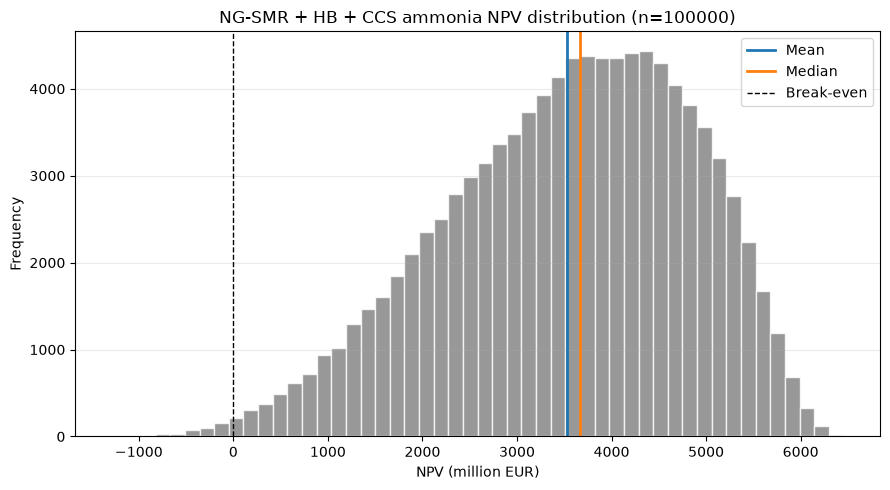

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"NG-SMR + HB + CCS ammonia NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()

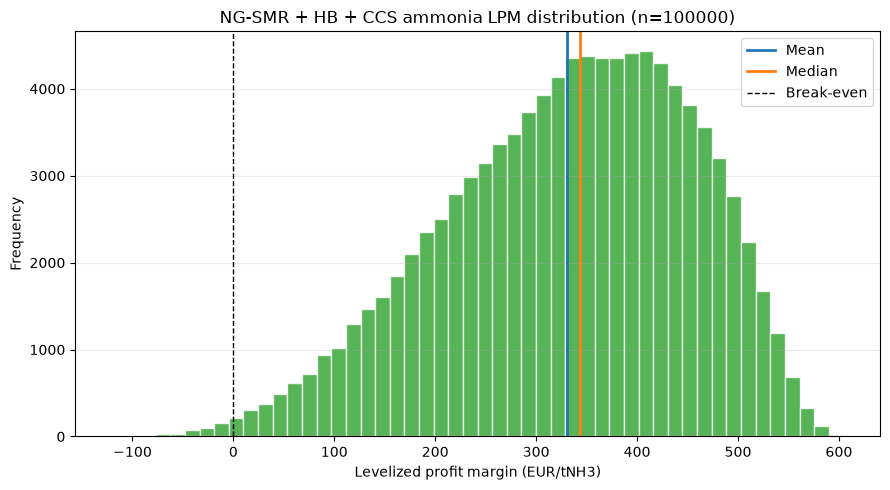

In [5]:
plot_financial_metric_distribution(
    levelized_profit_margin_eur_per_tnh3,
    title=f"NG-SMR + HB + CCS ammonia LPM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized profit margin (EUR/tNH3)",
    color="tab:green",
    show_break_even=True,
)
plt.show()

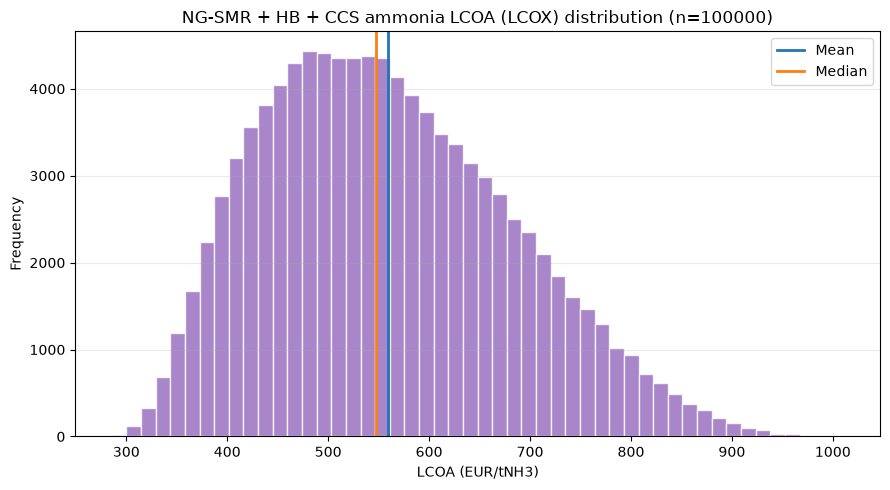

In [6]:
plot_financial_metric_distribution(
    lcoa_eur_per_tnh3,
    title=f"NG-SMR + HB + CCS ammonia LCOA (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOA (EUR/tNH3)",
    color="tab:purple",
)
plt.show()

In [7]:
annual_columns = [
    "annual_revenue_eur",
    "annual_fixed_opex_eur",
    "annual_variable_opex_eur",
    "annual_natural_gas_cost_eur",
    "annual_coal_cost_eur",
    "annual_biomass_cost_eur",
    "annual_fuel_cost_eur",
    "annual_electricity_cost_eur",
    "annual_transport_and_storage_cost_eur",
    "annual_emissions_cost_eur",
    "annual_net_cash_flow_eur",
]
(results[annual_columns] / 1_000_000).mean().rename("Mean annual value, million EUR")

annual_revenue_eur                      890.000
annual_fixed_opex_eur                    50.399
annual_variable_opex_eur                  8.950
annual_natural_gas_cost_eur             332.755
annual_coal_cost_eur                      0.000
annual_biomass_cost_eur                   0.000
annual_fuel_cost_eur                    332.755
annual_electricity_cost_eur              22.621
annual_transport_and_storage_cost_eur     9.471
annual_emissions_cost_eur                16.140
annual_net_cash_flow_eur                449.664
Name: Mean annual value, million EUR, dtype: float64

In [8]:
retrofit_columns = [
    column for column in results
    if column.startswith("bau_") or "_change_" in column
    or column == "emissions_reduction_fraction"
]
results[retrofit_columns].describe(percentiles=[0.05, 0.5, 0.95]).T

,count,mean,std,min,5%,50%,95%,max
bau_capex_eur_per_tnh3,"100,000.000","1,191.413",253.973,750.005,794.839,"1,193.043","1,586.853","1,629.988"
bau_fixed_opex_eur_per_tnh3,"100,000.000",29.399,0.123,29.101,29.195,29.399,29.606,29.699
bau_variable_opex_eur_per_tnh3,"100,000.000",8.950,0.000,8.950,8.950,8.950,8.950,8.950
bau_natural_gas_consumption_mwh_per_tnh3,"100,000.000",8.483,0.218,7.892,8.087,8.511,8.800,8.918
bau_electricity_consumption_mwh_per_tnh3,"100,000.000",0.000,0.000,0.000,0.000,0.000,0.000,0.000
bau_emissions_tco2_per_tnh3,"100,000.000",1.730,0.039,1.620,1.657,1.736,1.784,1.800
capex_change_eur_per_tnh3,"100,000.000",74.991,2.041,70.013,71.579,74.988,78.404,79.991
fixed_opex_change_eur_per_tnh3,"100,000.000",21.000,0.000,21.000,21.000,21.000,21.000,21.000
variable_opex_change_eur_per_tnh3,"100,000.000",0.000,0.000,0.000,0.000,0.000,0.000,0.000
natural_gas_consumption_change_mwh_per_tnh3,"100,000.000",0.000,0.000,0.000,0.000,0.000,0.000,0.000
